# In Real Decoder Only Transformer:
- In Training after each token the model generate next word only basis of the what it current token position
- Does not have any information about the tokens that are after current token

# The Sentence

In [26]:
sentence = 'river banks flow'

# Tokenization

In [2]:
tokens = sentence.split()
print(tokens)

token_map = {i: token for i, token in enumerate(tokens)}

print(token_map)

tokenized_sentence = [0, 1, 2]
print(f'{sentence}: {tokenized_sentence}')

['river', 'banks', 'flow']
{0: 'river', 1: 'banks', 2: 'flow'}
river banks flow: [0, 1, 2]


# Embedding
### For Simplicty We Will Use OneHotEncoding

In [3]:
def embedding_lookup(token_id):
    return token_map[token_id]


def token_embedding(token_id):
    embedding = [0] * len(token_map)
    embedding[token_id] = 1
    return embedding

In [4]:
sentence_embedded = [token_embedding(token_id) for token_id in tokenized_sentence]
print(f'{sentence.split()}')
sentence_embedded

['river', 'banks', 'flow']


[[1, 0, 0], [0, 1, 0], [0, 0, 1]]

# We Will Initilize Weight of the Query, Key, Value (Wq, Wk, Wv) Matrix
### For simplicity we used Identity Matrix for the all matrix

In [5]:
import numpy as np
Wq = np.eye(3)
Wk = Wq.copy()
Wv = Wq.copy()

print(f'Query Matrix: \n{Wq}\nKey Matrix: \n{Wk} \nValue Matrix: \n{Wv}')

Query Matrix: 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Key Matrix: 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]] 
Value Matrix: 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


# Linear Projection

In [6]:
Q = np.dot(sentence_embedded, Wq)
K = np.dot(sentence_embedded, Wk)
V = np.dot(sentence_embedded, Wv)

print(f'Query Vectors of "{sentence}": \n{Q}\nKey Vectors of "{sentence}": \n{K} \nValue Vectors of "{sentence}": \n{V}' )

Query Vectors of "river banks flow": 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Key Vectors of "river banks flow": 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]] 
Value Vectors of "river banks flow": 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


# Query, Key & Value vectors of Each Words

In [7]:
def show_vector(matrix, label):
    for ind, linear_projection in enumerate(matrix):
        print(f'{label} vector of {sentence.split(' ')[ind]}: {linear_projection}\n')
    print('---'*20)

show_vector(Q, 'Query')
show_vector(K, 'Key')
show_vector(V, 'Value')

Query vector of river: [1. 0. 0.]

Query vector of banks: [0. 1. 0.]

Query vector of flow: [0. 0. 1.]

------------------------------------------------------------
Key vector of river: [1. 0. 0.]

Key vector of banks: [0. 1. 0.]

Key vector of flow: [0. 0. 1.]

------------------------------------------------------------
Value vector of river: [1. 0. 0.]

Value vector of banks: [0. 1. 0.]

Value vector of flow: [0. 0. 1.]

------------------------------------------------------------


# Attention Calculation

In [8]:
def attention_calculation(Q, K):
    return np.dot(Q, K.T) / np.sqrt(Q.shape[1])

attention_scores = attention_calculation(Q, K)
print(f'Attention Scores: \n{attention_scores}')

Attention Scores: 
[[0.57735027 0.         0.        ]
 [0.         0.57735027 0.        ]
 [0.         0.         0.57735027]]


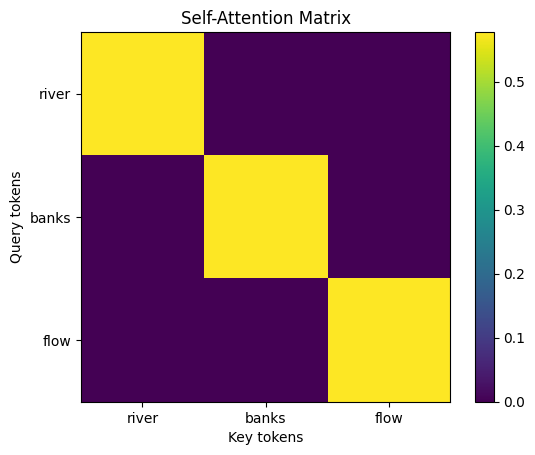

In [22]:
import matplotlib.pyplot as plt

plt.imshow(attention_scores, cmap='viridis')

plt.xticks(range(len(sentence.split())), sentence.split())
plt.yticks(range(len(sentence.split())), sentence.split())

plt.xlabel("Key tokens")
plt.ylabel("Query tokens")
plt.title("Self-Attention Matrix")

plt.colorbar()
plt.show()

# Calculate Masked-Score

In [23]:
mask = np.tril(np.ones((3, 3)))

print(mask)

masked_scores = np.where(mask == 0, -1e9, attention_scores)

print("\nMasked Scores:")
print(masked_scores)

[[1. 0. 0.]
 [1. 1. 0.]
 [1. 1. 1.]]

Masked Scores:
[[ 5.77350269e-01 -1.00000000e+09 -1.00000000e+09]
 [ 0.00000000e+00  5.77350269e-01 -1.00000000e+09]
 [ 0.00000000e+00  0.00000000e+00  5.77350269e-01]]


# Visualizing Masked Attention
- Because of Mask the current Token will not see any further tokens after itself
- Masker parts are show in purple color

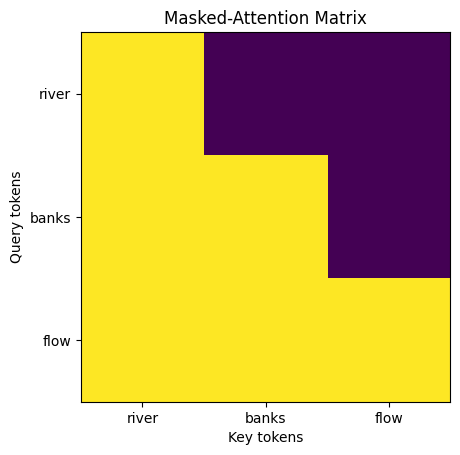

In [24]:
plt.imshow(masked_scores, cmap='viridis')

plt.xticks(range(len(sentence.split())), sentence.split())
plt.yticks(range(len(sentence.split())), sentence.split())

plt.xlabel("Key tokens")
plt.ylabel("Query tokens")
plt.title("Masked-Attention Matrix")
plt.show()

# Applying Softmax for Normalization

In [19]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=1, keepdims=True)

attention_weights = softmax(attention_scores)
print(f'Attention Weights: \n{attention_weights}')

Attention Weights: 
[[0.47108308 0.26445846 0.26445846]
 [0.26445846 0.47108308 0.26445846]
 [0.26445846 0.26445846 0.47108308]]


# Attention Output / Context Vector
### Visualization Given after It

In [20]:
attention_output  = V @ attention_weights.T
for ind, output in enumerate(attention_output):
    print(f'Attention output for {sentence.split()[ind]}: {output}\n')
    print(f'Which is calculated as:\n')
    print(f'\t\tVriver * {output[0]} + Vbanks * {output[1]} + Vflow * {output[2]}\n')
    print('-'*150)

Attention output for river: [0.47108308 0.26445846 0.26445846]

Which is calculated as:

		Vriver * 0.47108307700876034 + Vbanks * 0.26445846149561975 + Vflow * 0.26445846149561975

------------------------------------------------------------------------------------------------------------------------------------------------------
Attention output for banks: [0.26445846 0.47108308 0.26445846]

Which is calculated as:

		Vriver * 0.26445846149561975 + Vbanks * 0.47108307700876034 + Vflow * 0.26445846149561975

------------------------------------------------------------------------------------------------------------------------------------------------------
Attention output for flow: [0.26445846 0.26445846 0.47108308]

Which is calculated as:

		Vriver * 0.26445846149561975 + Vbanks * 0.26445846149561975 + Vflow * 0.47108307700876034

------------------------------------------------------------------------------------------------------------------------------------------------------


# Finally Visualization Attention Score or Similarity Score

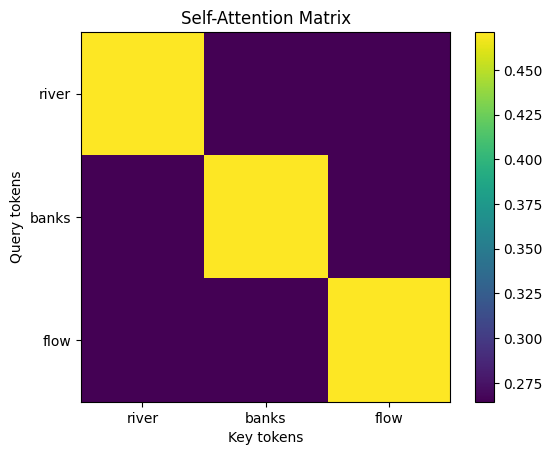

In [21]:
plt.imshow(attention_weights, cmap='viridis')

plt.xticks(range(len(sentence.split())), sentence.split())
plt.yticks(range(len(sentence.split())), sentence.split())

plt.xlabel("Key tokens")
plt.ylabel("Query tokens")
plt.title("Self-Attention Matrix")

plt.colorbar()
plt.show()